In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [98]:
df = pd.read_csv("/content/port_congestion.csv")

In [99]:
df.head()
print(df.shape)
print(df.info())
print(df.describe())
df.isnull().sum()

(6260, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6260 entries, 0 to 6259
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   week_start            6260 non-null   object 
 1   year                  6260 non-null   int64  
 2   port                  6260 non-null   object 
 3   country               6260 non-null   object 
 4   region                6260 non-null   object 
 5   throughput_teu_mn     6260 non-null   int64  
 6   vessels_at_anchor     6260 non-null   int64  
 7   avg_wait_days         6260 non-null   float64
 8   congestion_index      6260 non-null   float64
 9   port_utilization_pct  6260 non-null   float64
 10  berth_delay_hrs       6260 non-null   float64
dtypes: float64(4), int64(3), object(4)
memory usage: 538.1+ KB
None
              year  throughput_teu_mn  vessels_at_anchor  avg_wait_days  \
count  6260.000000        6260.000000        6260.000000    6260.000000   


,0
week_start,0
year,0
port,0
country,0
region,0
throughput_teu_mn,0
vessels_at_anchor,0
avg_wait_days,0
congestion_index,0
port_utilization_pct,0


In [100]:
df["congestion_level"] = pd.cut(
    df["congestion_index"],
    bins=[0, 0.8, 1.2, 10],
    labels=["Low", "Medium", "High"]
)

In [101]:
df["congestion_level"].value_counts()

,count
congestion_level,
High,4338
Medium,1775
Low,147


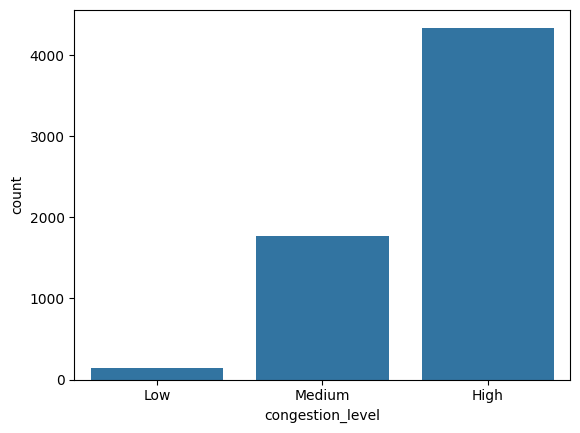

In [102]:
sns.countplot(x=df["congestion_level"])
plt.show()

In [103]:
X = df.drop(["congestion_level", "congestion_index"], axis=1)
y = df["congestion_level"]

In [104]:
X = pd.get_dummies(X, drop_first=True)

In [105]:
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

In [106]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [107]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [108]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5008, 352)
X_test : (1252, 352)
y_train: (5008,)
y_test : (1252,)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.9544728434504792
Precision: 0.955513992584702
Recall: 0.9544728434504792
F1 Score: 0.9454893089689732


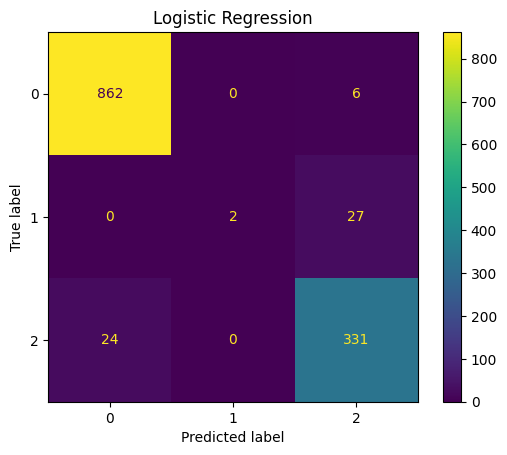

In [109]:
lr = LogisticRegression(max_iter=5000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred, average="weighted")
lr_recall = recall_score(y_test, lr_pred, average="weighted")
lr_f1 = f1_score(y_test, lr_pred, average="weighted")

print("Accuracy:", lr_accuracy)
print("Precision:", lr_precision)
print("Recall:", lr_recall)
print("F1 Score:", lr_f1)

cm = confusion_matrix(y_test, lr_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Logistic Regression")
plt.show()

Accuracy: 0.9624600638977636
Precision: 0.9624946076244252
Recall: 0.9624600638977636
F1 Score: 0.9601165999951635


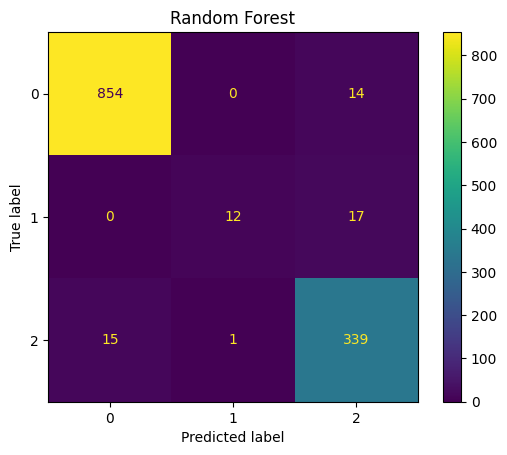

In [110]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, average="weighted")
rf_recall = recall_score(y_test, rf_pred, average="weighted")
rf_f1 = f1_score(y_test, rf_pred, average="weighted")

print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1 Score:", rf_f1)

cm = confusion_matrix(y_test, rf_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Random Forest")
plt.show()

Accuracy: 0.9281150159744409
Precision: 0.9231781695061667
Recall: 0.9281150159744409
F1 Score: 0.9215400578962095


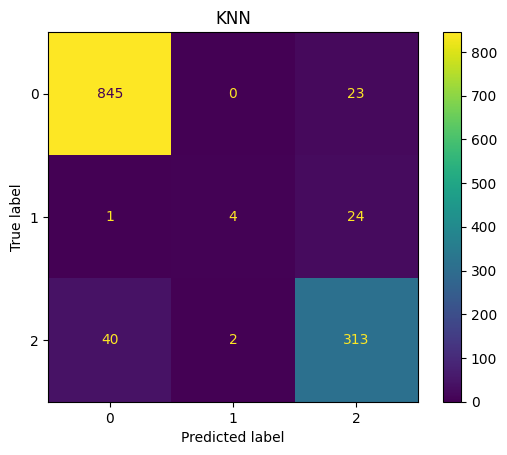

In [111]:
knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

knn_accuracy = accuracy_score(y_test, knn_pred)
knn_precision = precision_score(y_test, knn_pred, average="weighted")
knn_recall = recall_score(y_test, knn_pred, average="weighted")
knn_f1 = f1_score(y_test, knn_pred, average="weighted")

print("Accuracy:", knn_accuracy)
print("Precision:", knn_precision)
print("Recall:", knn_recall)
print("F1 Score:", knn_f1)

cm = confusion_matrix(y_test, knn_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("KNN")
plt.show()

In [112]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "KNN"],
    "Accuracy": [lr_accuracy, rf_accuracy, knn_accuracy],
    "Precision": [lr_precision, rf_precision, knn_precision],
    "Recall": [lr_recall, rf_recall, knn_recall],
    "F1 Score": [lr_f1, rf_f1, knn_f1]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.954473,0.955514,0.954473,0.945489
1,Random Forest,0.962460,0.962495,0.962460,0.960117
2,KNN,0.928115,0.923178,0.928115,0.921540


## Best Model Selection

Random Forest was the best-performing model with an Accuracy of 96.25% and an F1-Score of 96.01%.

Because the dataset is imbalanced, the F1-Score was used as the main evaluation metric. Based on the results, Random Forest was chosen as the final model.

In [113]:
num_classes = len(np.unique(y_train))

nn_model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

In [114]:
nn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [115]:
history = nn_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=32
)

Epoch 1/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7259 - loss: 0.6310 - val_accuracy: 0.8573 - val_loss: 0.3811
Epoch 2/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8525 - loss: 0.3871 - val_accuracy: 0.8932 - val_loss: 0.2777
Epoch 3/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8837 - loss: 0.2894 - val_accuracy: 0.9172 - val_loss: 0.2407
Epoch 4/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9076 - loss: 0.2329 - val_accuracy: 0.9202 - val_loss: 0.2159
Epoch 5/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9174 - loss: 0.2010 - val_accuracy: 0.9192 - val_loss: 0.2055
Epoch 6/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9391 - loss: 0.1543 - val_accuracy: 0.9271 - val_loss: 0.1913
Epoch 7/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9468 - loss: 0.1395 - val_accuracy: 0.9281 - val_loss: 0.1910
Epoch 8/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9483 - loss: 0.1279 - val_accuracy: 0.

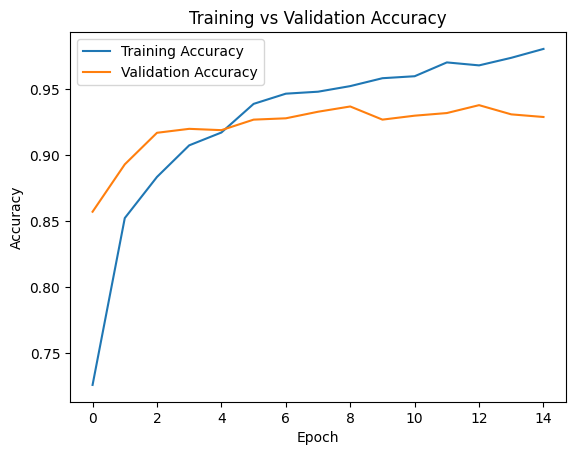

In [116]:
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

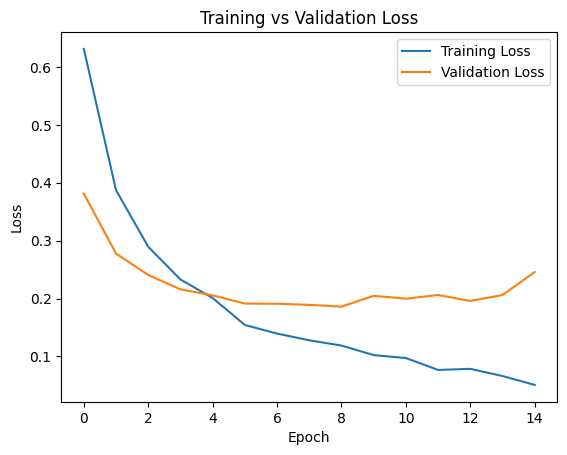

In [117]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [118]:
nn_pred_prob = nn_model.predict(X_test_scaled)
nn_pred = np.argmax(nn_pred_prob, axis=1)

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [119]:
nn_accuracy = accuracy_score(y_test, nn_pred)
nn_precision = precision_score(y_test, nn_pred, average="weighted")
nn_recall = recall_score(y_test, nn_pred, average="weighted")
nn_f1 = f1_score(y_test, nn_pred, average="weighted")

print("Accuracy:", nn_accuracy)
print("Precision:", nn_precision)
print("Recall:", nn_recall)
print("F1 Score:", nn_f1)

Accuracy: 0.9369009584664537
Precision: 0.9313354562056392
Recall: 0.9369009584664537
F1 Score: 0.9321943979957698


In [120]:
results.loc[len(results)] = [
    "Neural Network",
    nn_accuracy,
    nn_precision,
    nn_recall,
    nn_f1
]

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.954473,0.955514,0.954473,0.945489
1,Random Forest,0.962460,0.962495,0.962460,0.960117
2,KNN,0.928115,0.923178,0.928115,0.921540
3,Neural Network,0.936901,0.931335,0.936901,0.932194


## Neural Network Improvement

A StandardScaler was applied before training the Neural Network. This significantly improved the model performance.

The F1-score increased from 56.77% to 93.22% after scaling, demonstrating the importance of feature normalization for neural networks.

Although the Neural Network achieved strong results, Random Forest remained the best-performing model with an F1-score of 96.01%.

## Final Conclusion

Four models were evaluated: Logistic Regression, Random Forest, KNN, and Neural Network.

Random Forest achieved the highest performance with an Accuracy of 96.25% and an F1-Score of 96.01%. Since the dataset was imbalanced, the F1-Score was considered the primary evaluation metric.

Therefore, Random Forest was selected as the final model for port congestion classification.